In [28]:
import pandas as pd
import time
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup

# ---------------- Selenium Setup (VISIBLE BROWSER) ----------------

options = Options()
# REMOVE headless so browser is visible
# options.add_argument("--headless")  
options.add_argument("--disable-gpu")
options.add_argument("--start-maximized")  # start in full window

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

# ---------------- Target URL ----------------

url = "https://www.flipkart.com/apple-iphone-15-black-128-gb/product-reviews/itm6ac6485515ae4?pid=MOBGTAGPTB3VS24W&lid=LSTMOBGTAGPTB3VS24WCTBCFM&marketplace=FLIPKART"
driver.get(url)
time.sleep(3)

# ---------------- Data Lists ----------------

Username = []
Ratings = []
Review_text = []

target = 300        # number of reviews you want
max_pages = 30      # safety limit
page = 1

# ---------------- Scraping Loop ----------------

while len(Username) < target and page <= max_pages:
    print(f"Scraping page {page}...")

    soup = BeautifulSoup(driver.page_source, "lxml")

    # -------- Your Original BeautifulSoup Selectors --------

    # Username
    for name in soup.find_all("p", class_="zJ1ZGa ZDi3w2"):
        if len(Username) < target:
            Username.append(name.text.strip())

    # Ratings
    for rate in soup.find_all("div", class_="MKiFS6 ojKpP6"):
        if len(Ratings) < target:
            Ratings.append(rate.text.strip())

    # Review Text
    for rev in soup.find_all("div", class_="G4PxIA"):
        if len(Review_text) < target:
            text = rev.text.strip().replace("READ MORE", "").strip()
            Review_text.append(text)

    # ---------------------------------------------------------

    # Next Page Button
    try:
        next_btn = driver.find_element(By.XPATH, "//span[text()='Next']")
        driver.execute_script("arguments[0].click();", next_btn)
        time.sleep(3)
        page += 1
    except:
        print("No next button found – end of pages.")
        break

# Close Browser After Scraping
driver.quit()

# ---------------- Normalize List Lengths ----------------

min_len = min(len(Username), len(Ratings), len(Review_text))
Username = Username[:min_len]
Ratings = Ratings[:min_len]
Review_text = Review_text[:min_len]

# ---------------- Save to CSV ----------------

df = pd.DataFrame({
    "Username": Username,
    "Ratings": Ratings,
    "Review_text": Review_text
})

print(f"\nCollected {len(df)} reviews successfully!")

df.to_csv("final_reviews.csv", index=False)
print("Saved to flipkart_reviews_final.csv")


Scraping page 1...
Scraping page 2...
Scraping page 3...
Scraping page 4...
Scraping page 5...
Scraping page 6...
Scraping page 7...
Scraping page 8...
Scraping page 9...
Scraping page 10...
Scraping page 11...
Scraping page 12...
Scraping page 13...
Scraping page 14...
Scraping page 15...
Scraping page 16...
Scraping page 17...
Scraping page 18...
Scraping page 19...
Scraping page 20...
Scraping page 21...
Scraping page 22...
Scraping page 23...
Scraping page 24...
Scraping page 25...
Scraping page 26...
Scraping page 27...
Scraping page 28...
Scraping page 29...
Scraping page 30...

Collected 300 reviews successfully!
Saved to flipkart_reviews_final.csv


In [29]:
# cleaning.py
"""
Standalone cleaning script for scraped Flipkart reviews.

Usage:
    python cleaning.py
    python cleaning.py --input path/to/final_reviews.csv --output path/to/final_reviews_cleaned.csv
    python cleaning.py --no-nlp          # skip tokenization/lemmatization step (faster)

Outputs:
    final_reviews_cleaned.csv  (by default, in current working directory)
"""

import os
import re
import sys
import argparse
import string
import pandas as pd

# NLP imports - we handle downloads / fallbacks
try:
    import nltk
    from nltk.tokenize import word_tokenize
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer
except Exception:
    nltk = None

# ----------------- Config -----------------
DEFAULT_INPUT = "final_reviews.csv"
DEFAULT_OUTPUT = "final_reviews_cleaned.csv"

# Pagination regex (non-capturing)
PAGINATION_RE = re.compile(r'\b(?:Page\s*\d+(?:\s*of\s*\d+)?|Next|Prev(?:ious)?|Show more)\b', re.IGNORECASE)

# ----------------- NLTK helpers -----------------
def ensure_nltk_resources():
    """Attempt to ensure required NLTK models are present. Non-fatal if downloads fail."""
    if not nltk:
        print("[NLTK] nltk module not available; NLP steps will use fallback.")
        return

    resources = {
        'punkt': 'tokenizers/punkt',
        'stopwords': 'corpora/stopwords',
        'wordnet': 'corpora/wordnet',
        'omw-1.4': 'corpora/omw-1.4'
    }
    for short, loc in resources.items():
        try:
            nltk.data.find(loc)
        except LookupError:
            try:
                print(f"[NLTK] Downloading resource: {short} ...")
                nltk.download(short, quiet=True)
            except Exception as e:
                print(f"[NLTK] Could not download {short}: {e}")

# initialize lemmatizer and stopwords (with safe fallback)
def init_nlp_components():
    ensure_nltk_resources()
    lemmatizer = WordNetLemmatizer() if nltk else None
    try:
        stop_words = set(stopwords.words('english')) if nltk else set()
    except Exception:
        stop_words = {"the","is","in","and","to","a","of","it","for","this","that","i","you"}
    return lemmatizer, stop_words

LEMMATIZER, STOP_WORDS = init_nlp_components()

# ----------------- Text cleaning helpers -----------------
def remove_emojis_and_nontext(s: str) -> str:
    if not isinstance(s, str):
        return ""
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F700-\U0001F77F"
        "\U0001F780-\U0001F7FF"
        "\U0001F800-\U0001F8FF"
        "\U0001F900-\U0001F9FF"
        "\U0001FA00-\U0001FA6F"
        "\U0001FA70-\U0001FAFF"
        "\u2600-\u26FF\u2700-\u27BF]+",
        flags=re.UNICODE,
    )
    return emoji_pattern.sub("", s)

def clean_text_basic(s: str) -> str:
    """Basic cleaning:
       - remove 'READ MORE', pagination words
       - remove emojis, URLs, weird unicode
       - collapse whitespace
    """
    if not isinstance(s, str):
        return ""
    s = s.strip()
    s = re.sub(r'READ\s*MORE', ' ', s, flags=re.IGNORECASE)
    s = PAGINATION_RE.sub(' ', s)
    s = remove_emojis_and_nontext(s)
    s = s.replace('\u2019', "'").replace('\u201c', '"').replace('\u201d', '"')
    s = re.sub(r'http\S+|www\.\S+', '', s)
    # keep basic punctuation for now, remove other symbols
    s = re.sub(r'[^0-9a-zA-Z\s\.\,\?\!\']', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def normalize_text_for_nlp(s: str, remove_punct=True) -> str:
    s = s.lower()
    if remove_punct:
        s = s.translate(str.maketrans('', '', string.punctuation))
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def nlp_preprocess_safe(s: str, keep_stopwords=False) -> str:
    """Tokenize, remove stopwords (optional), lemmatize. Fallbacks if NLTK resources missing."""
    if not isinstance(s, str) or s.strip() == "":
        return ""
    s = clean_text_basic(s)
    s = normalize_text_for_nlp(s, remove_punct=True)

    # tokenize with NLTK if available, otherwise simple split
    tokens = []
    if nltk:
        try:
            tokens = word_tokenize(s)
        except Exception:
            tokens = s.split()
    else:
        tokens = s.split()

    if not keep_stopwords and STOP_WORDS:
        tokens = [t for t in tokens if t not in STOP_WORDS]

    # lemmatize if possible
    if LEMMATIZER:
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    # else leave tokens as-is

    return " ".join(tokens)

# ----------------- Main preprocessing function -----------------
def preprocess_reviews(input_csv: str, output_csv: str, do_nlp: bool = True) -> pd.DataFrame:
    # determine absolute paths
    input_csv = os.path.abspath(input_csv)
    output_csv = os.path.abspath(output_csv)

    if not os.path.exists(input_csv):
        raise FileNotFoundError(f"Input CSV not found at: {input_csv}\nRun the scraper first or provide correct path.")

    print(f"Loading CSV from: {input_csv}")
    df = pd.read_csv(input_csv, encoding='utf-8', dtype=str).fillna("")

    # ensure expected column exists
    if 'Review_text' not in df.columns:
        raise ValueError("Input CSV must contain a 'Review_text' column (exact name).")

    # Basic cleaning
    print("Cleaning review text (basic)...")
    df['Review_text_clean'] = df['Review_text'].astype(str).apply(clean_text_basic)

    # Filter out pagination/junk/too-short
    print("Filtering out pagination/junk/too-short rows...")
    bad_mask = df['Review_text_clean'].str.contains(PAGINATION_RE, na=False, regex=True)
    tiny_mask = df['Review_text_clean'].str.len() < 10
    numeric_mask = df['Review_text_clean'].str.fullmatch(r'[\d\W]+', na=False)
    removal_mask = bad_mask | tiny_mask | numeric_mask
    removed_count = removal_mask.sum()
    if removed_count:
        print(f" - Removing {removed_count} rows flagged as pagination/junk/too-short")
    df = df[~removal_mask].copy()

    # Deduplicate by cleaned text
    before = len(df)
    df.drop_duplicates(subset=['Review_text_clean'], inplace=True)
    print(f" - Dropped {before - len(df)} duplicate rows")

    # Normalize Ratings column if present
    if 'Ratings' in df.columns:
        print("Normalizing Ratings to numeric...")
        df['Ratings'] = df['Ratings'].astype(str).apply(lambda x: re.sub(r'[^0-9\.]', '', x)).replace('', pd.NA)
        df['Ratings'] = pd.to_numeric(df['Ratings'], errors='coerce')
        if df['Ratings'].isna().sum() > 0:
            median_rating = df['Ratings'].median(skipna=True)
            df['Ratings'] = df['Ratings'].fillna(median_rating)
            print(f" - Filled missing Ratings with median: {median_rating}")

    # NLP preprocessing (optional)
    if do_nlp:
        print("Running NLP preprocessing (tokenize, remove stopwords, lemmatize)...")
        df['Review_text_lemmatized'] = df['Review_text_clean'].apply(nlp_preprocess_safe)
    else:
        print("Skipping NLP step; producing normalized lowercase text instead.")
        df['Review_text_lemmatized'] = df['Review_text_clean'].apply(lambda s: normalize_text_for_nlp(s, remove_punct=True))

    # Save cleaned CSV
    df.to_csv(output_csv, index=False, encoding='utf-8-sig')
    print(f"Saved cleaned CSV to: {output_csv} (rows: {len(df)})")
    return df

# ----------------- CLI -----------------
def main_cli():
    parser = argparse.ArgumentParser(description="Clean and preprocess scraped reviews (Pandas + optional NLTK).")
    parser.add_argument("--input", "-i", default=DEFAULT_INPUT, help="Input raw CSV (default: final_reviews.csv)")
    parser.add_argument("--output", "-o", default=DEFAULT_OUTPUT, help="Output cleaned CSV (default: final_reviews_cleaned.csv)")
    parser.add_argument("--no-nlp", action="store_true", help="Skip NLP tokenization/lemmatization (faster)")

    args = parser.parse_known_args()[0]

    try:
        df_clean = preprocess_reviews(args.input, args.output, do_nlp=not args.no_nlp)
    except Exception as e:
        print("ERROR:", e)
        sys.exit(1)

    print("\nSample cleaned rows (first 5):")
    to_show = ['Username','Ratings','Review_text_clean','Review_text_lemmatized']
    available = [c for c in to_show if c in df_clean.columns]
    print(df_clean[available].head(5).to_dict(orient='records'))

if __name__ == "__main__":
    main_cli()


[NLTK] Downloading resource: wordnet ...
[NLTK] Downloading resource: omw-1.4 ...
Loading CSV from: C:\Users\ASUS\final_reviews.csv
Cleaning review text (basic)...
Filtering out pagination/junk/too-short rows...
 - Removing 33 rows flagged as pagination/junk/too-short
 - Dropped 3 duplicate rows
Normalizing Ratings to numeric...
Running NLP preprocessing (tokenize, remove stopwords, lemmatize)...
Saved cleaned CSV to: C:\Users\ASUS\final_reviews_cleaned.csv (rows: 264)

Sample cleaned rows (first 5):
[{'Username': 'Arunji Govindaraju', 'Ratings': 5, 'Review_text_clean': 'Awesome product very happy to hold this. Better In hand feel,matte finish. Good camera, Brighter screen with Dynamic Island, USB C, great battery life.60Hz display is a dealbreaker for some.Its not much noticeable.Thank u Flipkart for the best deal and quick delivery.', 'Review_text_lemmatized': 'awesome product happy hold better hand feelmatte finish good camera brighter screen dynamic island usb c great battery life6

In [5]:
import nltk 


In [13]:
from textblob import TextBlob


## Step 3: Sentiment Analysis

**Tool Used:** TextBlob

**Objective:**  
To analyze the sentiment of each scraped review and classify it as
Positive or Negative.

**Methodology:**
- TextBlob is used to calculate the polarity score of each review.
- Polarity ranges from -1 (negative) to +1 (positive).
- A threshold of 0.1 is used for classification:
  - Polarity ≥ 0.1 → Positive
  - Polarity < 0.1 → Negative

**Output:**
The sentiment label is stored for each review in the dataset.


In [31]:
from textblob import TextBlob

df["polarity"] = df["Review_text"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df["sentiment"] = df["polarity"].apply(
    lambda x: "Positive" if x >= 0.1 else "Negative"
)

df.head(20)


,Username,Ratings,Review_text,polarity,sentiment
0,Arunji Govindaraju,5,Awesome product very happy to hold this. Bette...,0.581481,Positive
1,Rishabh Jha,5,Awesome 🔥🔥☺️,1.000000,Positive
2,Akshay Meena,5,"So beautiful, so elegant, just a vowww😍❤️",0.675000,Positive
3,Neeraj Chouhan,5,Amezing camera and all over best phone👌,1.000000,Positive
4,Nikhil Kumar,5,Switch from OnePlus to iPhone I am stunned wit...,1.000000,Positive
5,Mousam Guha Roy,4,Very nice,0.780000,Positive
6,Ajin V,5,High quality camera😍,0.160000,Positive
7,Flipkart Customer,5,Awesome photography experience. Battery backup...,0.733333,Positive
8,Thakur Surya Pratap Singh,5,Awesome 😎,1.000000,Positive
9,Prithivi Boruah,5,Camera Quality Is Improved Loving It,0.600000,Positive


In [32]:
df = pd.read_csv("final_reviews_cleaned.csv")


In [33]:
from textblob import TextBlob

df["polarity"] = df["Review_text"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

df["sentiment"] = df["polarity"].apply(
    lambda x: "Positive" if x >= 0.1 else "Negative"
)


In [34]:
df.to_csv("flipkart_reviews_with_sentiment.csv", index=False)


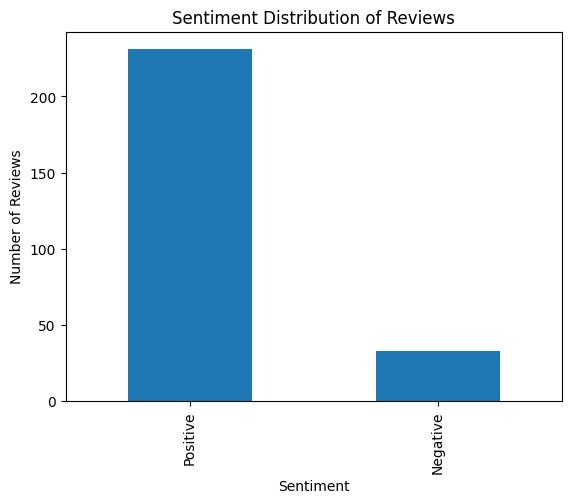

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_counts = df["sentiment"].value_counts()

plt.figure()
sentiment_counts.plot(kind="bar")
plt.title("Sentiment Distribution of Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()


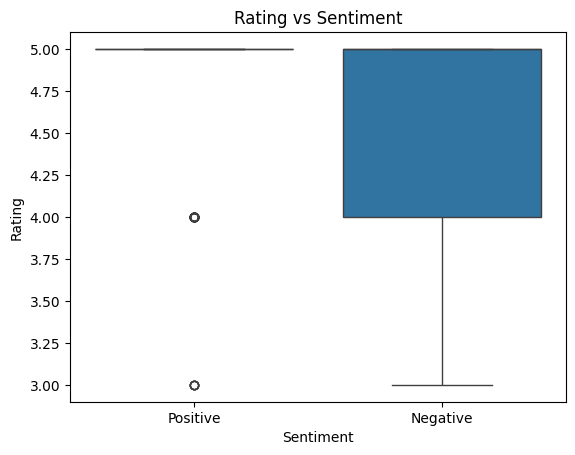

In [46]:
plt.figure()
sns.boxplot(x="sentiment", y="Ratings", data=df)
plt.title("Rating vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Rating")
plt.show()


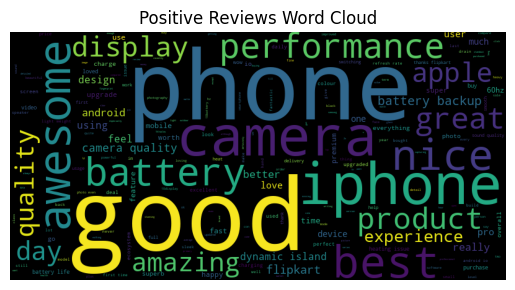

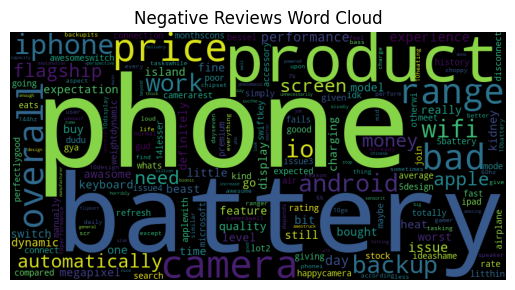

In [36]:
from wordcloud import WordCloud
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("flipkart_reviews_with_sentiment.csv")   
positive_text = " ".join(df[df["sentiment"] == "Positive"]["Review_text_lemmatized"])
negative_text = " ".join(df[df["sentiment"] == "Negative"]["Review_text_lemmatized"])

wc_pos = WordCloud(width=800, height=400).generate(positive_text)
wc_neg = WordCloud(width=800, height=400).generate(negative_text)

plt.figure()
plt.imshow(wc_pos)
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()
plt.figure()
plt.imshow(wc_neg)
plt.axis("off")
plt.title("Negative Reviews Word Cloud")
plt.show()


In [39]:
import pandas as pd
from textblob import TextBlob

df = pd.read_csv("flipkart_reviews_with_sentiment.csv")

df.columns = df.columns.str.strip().str.lower()

df["polarity"] = df["review_text"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

df["sentiment"] = df["polarity"].apply(
    lambda x: "Positive" if x >= 0.1 else "Negative"
)

df.to_csv("flipkart_reviews_final.csv", index=False)

df.head()


,username,ratings,review_text,review_text_clean,review_text_lemmatized,polarity,sentiment
0,Arunji Govindaraju,5,Awesome product very happy to hold this. Bette...,Awesome product very happy to hold this. Bette...,awesome product happy hold better hand feelmat...,0.581481,Positive
1,Akshay Meena,5,"So beautiful, so elegant, just a vowww😍❤️","So beautiful, so elegant, just a vowww",beautiful elegant vowww,0.675000,Positive
2,Neeraj Chouhan,5,Amezing camera and all over best phone👌,Amezing camera and all over best phone,amezing camera best phone,1.000000,Positive
3,Nikhil Kumar,5,Switch from OnePlus to iPhone I am stunned wit...,Switch from OnePlus to iPhone I am stunned wit...,switch oneplus iphone stunned camera performan...,1.000000,Positive
4,Ajin V,5,High quality camera😍,High quality camera,high quality camera,0.160000,Positive


In [40]:
df["review_length"] = df["review_text"].apply(
    lambda x: len(str(x).split())
)


In [41]:
df["sentiment_strength"] = df["polarity"].abs()


In [44]:
correlation = df["review_length"].corr(df["sentiment_strength"])
print("Correlation:", correlation)


Correlation: -0.373826381833532


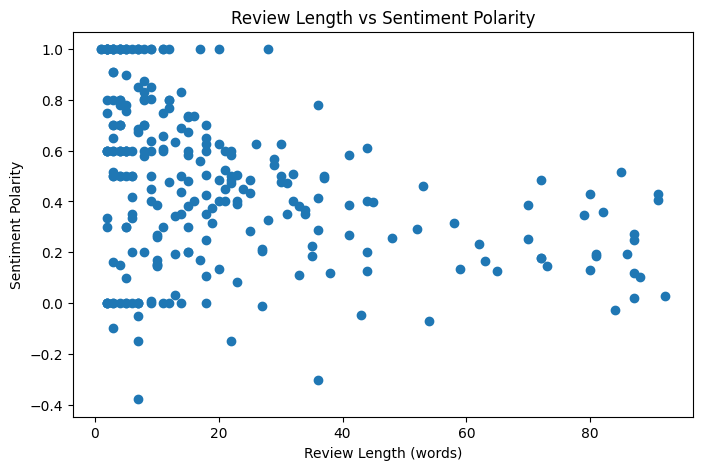

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df["review_length"], df["polarity"])
plt.xlabel("Review Length (words)")
plt.ylabel("Sentiment Polarity")
plt.title("Review Length vs Sentiment Polarity")
plt.show()


In [46]:
df.to_csv("flipkart_reviews_with_length_analysis.csv", index=False)
